<h2 style="color:blue" align="center">California Housing Price Prediction</h2>

#### Import the necessary libraries

In [1]:
import random as python_random
import time, math 
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

import tensorflow as tf
from tensorflow import keras 
from keras.models import Sequential
from keras.layers import Dense 
from keras.callbacks import Callback, CSVLogger   

import warnings
warnings.filterwarnings('ignore')

#### Reserve GPU memory for the execution

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

1 Physical GPUs, 1 Logical GPUs


#### Load the dataset

In [3]:
df = pd.read_csv('../Dataset/California housing price.csv')

In [4]:
df.shape

(20640, 10)

#### Data pre-processing

In [5]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
# Dropping NA
df = df.dropna() 

In [7]:
one_hot_encoders_data =  pd.get_dummies(df)
one_hot_encoders_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [8]:
cols = one_hot_encoders_data.columns
df = pd.DataFrame(one_hot_encoders_data,columns= cols)
df.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
19846,-119.10,36.40,23.0,1885.0,363.0,1056.0,338.0,3.2159,92800.0,0,1,0,0,0
3920,-118.56,34.20,36.0,1544.0,308.0,891.0,286.0,4.1750,190900.0,1,0,0,0,0
6371,-118.00,34.15,48.0,3436.0,673.0,1540.0,648.0,4.2750,256800.0,0,1,0,0,0
15136,-116.92,32.84,16.0,4675.0,834.0,2188.0,817.0,4.6674,178000.0,1,0,0,0,0
18007,-121.96,37.29,24.0,1240.0,263.0,690.0,276.0,5.0000,283000.0,1,0,0,0,0


In [9]:
df.drop(['longitude','latitude'],axis=1,inplace=True)

In [10]:
X = df.drop(['median_house_value'], axis = 1)
Y = df['median_house_value' ].values

In [11]:
# Remove the outliers
rs = RobustScaler()
robust_df = rs.fit_transform(X) 
robust_df = pd.DataFrame(robust_df, columns=list(X.columns))

In [12]:
# Normalize the input dataset
scaler_MinMax1 = MinMaxScaler()
X = scaler_MinMax1.fit_transform(robust_df) 
scaler_MinMax2 = MinMaxScaler()
Y = scaler_MinMax2.fit_transform(pd.DataFrame(Y)) 

#### Split the dataset into training and testing set

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0) 

In [14]:
X_train.shape

(16346, 11)

#### Define DNN model

In [15]:
python_random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)
opti_name = ''

def get_model(): 
    tf.keras.backend.clear_session()
    model = Sequential([ 
        Dense(512, input_dim = 11, activation='relu'),
        Dense(256, activation='relu'),  
        Dense(64, activation='relu'),  
        Dense(1, activation='linear')
    ], name = "DNN_model")
    
    global opti_name 
    
    # General SGD
    opti = keras.optimizers.SGD(learning_rate=0.001)
    opti_name = 'SGD'
    
    # Momentum
    #opti = keras.optimizers.SGD(learning_rate=0.001, momentum=0.6)
    #opti_name = 'Momentum'
    
    # Nesterov Accelerated Gradient 
    #opti = keras.optimizers.SGD(learning_rate=0.001, momentum=0.4, nesterov=True)
    #opti_name = 'NAG'
    
    # Adagrad
    #opti = keras.optimizers.Adagrad(learning_rate=0.001) 
    #opti_name = 'AdaGrad' 
    
    # RMSprop 
    #opti = keras.optimizers.RMSprop(learning_rate=0.001)
    #opti_name = 'RMSprop'
    
    # Adadelta
    #opti = keras.optimizers.Adadelta(learning_rate=0.001) 
    #opti_name = 'AdaDelta' 
    
    # Adam
    #opti = keras.optimizers.Adam(learning_rate=0.001) 
    #opti_name = 'Adam'     
    
    # Adamax
    #opti = keras.optimizers.Adamax(learning_rate=0.001) 
    #opti_name = 'AdaMax'
    
    # Nadam
    #opti = keras.optimizers.Nadam(learning_rate=0.001) 
    #opti_name = 'Nadam'  
    
    model.compile(
        optimizer = opti,
        loss = 'mse'  
    )
    
    return model

#### Custom callbacks

HMS

In [16]:
class CustomCallbackHMS(Callback):  
    initial_weights = 0
    previous_weights = 0
    call_hm = 0 
    temp_model = 0
    r = 1
    t = 100
    
    def __init__(self, mod):
        self.temp_model = mod
        
    def on_train_begin(self, logs=None):
        self.initial_weights = self.temp_model.get_weights() 
        self.initial_weights = np.array(self.initial_weights,dtype=object)
        self.previous_weights = self.initial_weights
        # Harmonic mean based weights calculation
        self.call_hm = np.vectorize(self.apply_hm)  
             
    def on_epoch_end(self, epoch, logs={}):    
        # Minimizing HMS factor every 100 epoch
        if (epoch+1)%self.t == 0:
            self.r = round(self.r *0.9,4)  
        
        num_layers = len(self.temp_model.layers)  
        current_weights = self.temp_model.get_weights()
        current_weights = np.array(current_weights,dtype=object)        

        for i in range(num_layers):  
            # Harmonic mean based weights calculation
            tensor1 = tf.convert_to_tensor(self.previous_weights[i])
            tensor2 = tf.convert_to_tensor(current_weights[i])
            current_weights[i] = self.call_hm(tensor1, tensor2, self.r)   
            
        # Updating the model with new weights
        self.temp_model.set_weights(current_weights.tolist())
        self.previous_weights = current_weights
        
    def apply_hm(self, v1, v2, r): 
        # HMS calculation   
        if v1==0 or v2==0:
            return v2
        elif v1 > v2:
            t1 = abs(v1)
            t2 = abs(v2)
            hm = 2*t1*t2/(t1+t2)
            min1 = min(t1,t2)
            hms = abs(hm-min1)*r
            v2 = v2 - hms
            return v2  
        elif v1 < v2:
            t1 = abs(v1)
            t2 = abs(v2)
            hm = 2*t1*t2/(t1+t2)
            min1 = min(t1,t2)
            hms = abs(hm-min1)*r
            v2 = v2 + hms
            return v2   
        else:
            return v2   

#### Training

Get a model to assign same weights to model with and without HMS

In [17]:
model = get_model() 
weights = model.get_weights() 
num_epochs = 1000
Full = X_train.shape[0]
batch_size = Full     # Full / 256 / 64 / 16

To record loss and accuracy in CSV file

In [18]:
generic_file = 'Results/California/'+ opti_name +' optimizer.csv'
hms_file = 'Results/California/'+ opti_name +' HMS optimizer.csv' 
logger_generic_model = CSVLogger(generic_file, append = False, separator=',')
logger_hms_model = CSVLogger(hms_file, append = False, separator=',')

Generic opimizer model

In [19]:
model_wihtout_hms = get_model()
model_wihtout_hms.set_weights(weights) 
st = time.time() 
model_wihtout_hms.fit(X_train, y_train, epochs = num_epochs, verbose=0, callbacks=[logger_generic_model], batch_size=batch_size) 
et = time.time()
elapsed_training_time_generic = round(et - st, 4)
print('Execution time:', elapsed_training_time_generic, 'seconds') 

Execution time: 2.746 seconds


HMS-based optimizer model

In [20]:
model_with_hms = get_model()
model_with_hms.set_weights(weights) 
st = time.time()
model_with_hms.fit(X_train, y_train, epochs = num_epochs, verbose=0, callbacks=[CustomCallbackHMS(model_with_hms),logger_hms_model], batch_size=batch_size) 
et = time.time()
elapsed_training_time_hms = round(et - st, 4)
print('Execution time:', elapsed_training_time_hms, 'seconds') 

Execution time: 38.8187 seconds


Model summary

In [21]:
model_with_hms.summary()

Model: "DNN_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               6144      
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 64)                16448     
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 153,985
Trainable params: 153,985
Non-trainable params: 0
_________________________________________________________________


#### Generic optimizer vs HMS-based optimizer

In [22]:
df1 = pd.read_csv(generic_file)
df2 = pd.read_csv(hms_file)

Loss

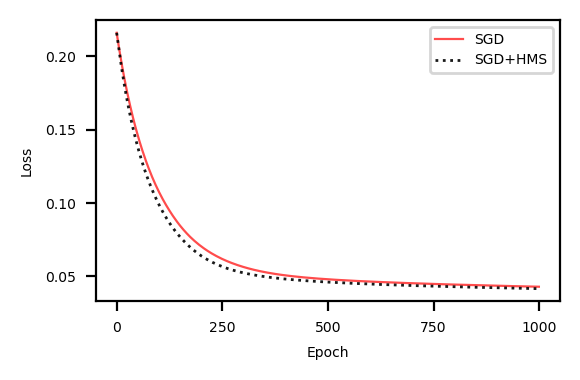

In [23]:
x1 = range(0, df1.shape[0])
x2 = range(0, df2.shape[0])
y1 = df1['loss'] 
y2 = df2['loss']  
plt.figure(figsize = (3,2), dpi = 200)
plt.plot(x1, y1, "r-", label = opti_name, linewidth = 0.8, alpha = 0.7)
plt.plot(x2, y2, "k:", label = opti_name+'+HMS', linewidth = 1, alpha = 0.9) 
plt.ylabel('Loss' , fontdict = {'fontsize':5})
plt.xlabel('Epoch', fontdict = {'fontsize':5}) 
#plt.yscale('log')
#plt.title("Loss", fontdict = {'fontname':'Times New Roman', 'fontsize':8})
plt.xticks(fontsize = 5)
plt.yticks(fontsize = 5)
plt.tight_layout()
plt.legend(prop={'size': 5})
#plt.savefig("graph.png",bbox_inches='tight',dpi=(300)) 
plt.show()

#### Training cost

In [24]:
print(f'Taining cost on {opti_name} = {round(df1.iloc[num_epochs-1].loss, 3)}')
print(f'Taining cost on {opti_name}+HMS = {round(df2.iloc[num_epochs-1].loss, 3)}')

Taining cost on SGD = 0.043
Taining cost on SGD+HMS = 0.042


#### Testing the model

Generic opimizer model

In [25]:
generic_testing_cost = model_wihtout_hms.evaluate(X_test, y_test)
generic_testing_cost  

128/128 [==============================] - 0s 521us/step - loss: 0.0434


0.043371476233005524

HMS-based optimizer model

In [26]:
hms_testing_cost = model_with_hms.evaluate(X_test, y_test)
hms_testing_cost

128/128 [==============================] - 0s 562us/step - loss: 0.0421


0.042064908891916275

<h2 style="color:blue" align="center">Training Loss vs Validation Loss</h2>

For generic optimizer

In [27]:
model_wihtout_hms_val = get_model()
model_wihtout_hms_val.set_weights(weights) 
history = model_wihtout_hms_val.fit(X_train, y_train, epochs = num_epochs, verbose=0, validation_split=0.2, batch_size=batch_size) 

In [28]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

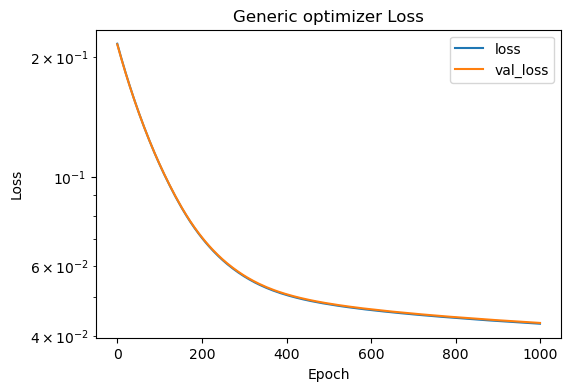

In [29]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Generic optimizer Loss')
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show()

For HMS-based optimizer

In [30]:
model_with_hms_val = get_model()
model_with_hms_val.set_weights(weights) 
history_hms = model_with_hms_val.fit(X_train, y_train, epochs = num_epochs, verbose=0, validation_split=0.2, callbacks=[CustomCallbackHMS(model_with_hms_val)], batch_size=batch_size) 

In [32]:
history_hms.history.keys()

dict_keys(['loss', 'val_loss'])

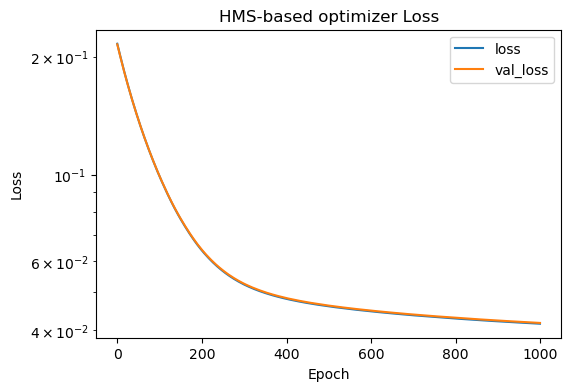

In [33]:
plt.figure(figsize=(6,4))
plt.plot(history_hms.history['loss'])
plt.plot(history_hms.history['val_loss'])
plt.title('HMS-based optimizer Loss')
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show()

<h2 style="color:blue" align="center">Validation with 10 Random Executionsn</h2>

In [36]:
num_exe = 10 
loss = [] 
loss_hms = []  

for i in tqdm(np.arange(num_exe)):  
        # Load data
        X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)  
        temp_model = get_model()
        temp_weights = temp_model.get_weights()  

        # Model without HMS    
        val_model = get_model()
        val_model.set_weights(temp_weights)    
        val_model.fit(X_train, y_train, epochs = num_epochs, verbose = 0, batch_size = batch_size) 
        scores = val_model.evaluate(X_test, y_test, verbose = 0)
        loss.append(round(scores, 4)) 

        # Model with HMS
        val_model_hms = get_model()
        val_model_hms.set_weights(temp_weights)     
        val_model_hms.fit(X_train, y_train, epochs = num_epochs, verbose = 0, callbacks=[CustomCallbackHMS(val_model_hms)], batch_size = batch_size) 
        scores_hms = val_model_hms.evaluate(X_test, y_test, verbose = 0)
        loss_hms.append(round(scores_hms, 4)) 
        #print('Execution ',i, 'is completed') 

results = pd.DataFrame(list(zip(loss, loss_hms)), columns = [opti_name, opti_name+'+HMS'])
results.to_csv('Results/California/'+opti_name+' summary.csv') 

100%|██████████| 10/10 [07:13<00:00, 43.33s/it]


In [37]:
print('----------------------------------------------') 
print(f'                {opti_name} vs {opti_name}+HMS     ')
print('----------------------------------------------')
print(f'Training set size     : {X_train.shape[0]} samples        ')
print(f'Batch size            : {batch_size} samples      ')
print('----------------------------------------------')
print(f'Training time for single run with {num_epochs} epochs')
print('----------------------------------------------')
print(f'{opti_name}           : {round(elapsed_training_time_generic,4)} seconds') 
print(f'{opti_name}+HMS       : {round(elapsed_training_time_hms,4)} seconds')
print('----------------------------------------------')
print(f'Training cost for single run                 ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(df1.iloc[num_epochs-1].loss, 4)}') 
print(f'{opti_name}+HMS       : {round(df2.iloc[num_epochs-1].loss, 4)}')
print('----------------------------------------------')
print(f'Testing cost for single run                 ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(generic_testing_cost, 4)}') 
print(f'{opti_name}+HMS       : {round(hms_testing_cost, 4)}')
print('----------------------------------------------')   
print('''Test set loss on different runs with different 
          weights initilization''')
print('----------------------------------------------')
print(results)
print('----------------------------------------------')
print('            Average loss with test set        ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(results[results.columns[0]].mean(),4)} (+- {round(results[results.columns[0]].std(),4)})')
print(f'{opti_name}+HMS       : {round(results[results.columns[1]].mean(),4)} (+- {round(results[results.columns[1]].std(),4)})')
print('----------------------------------------------') 
print('       Model that produces minimum loss       ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(results[results.columns[0]].min(),4)}')
print(f'{opti_name}+HMS       : {round(results[results.columns[1]].min(),4)}')
print('----------------------------------------------') 

----------------------------------------------
                SGD vs SGD+HMS     
----------------------------------------------
Training set size     : 16346 samples        
Batch size            : 16346 samples      
----------------------------------------------
Training time for single run with 1000 epochs
----------------------------------------------
SGD           : 2.746 seconds
SGD+HMS       : 38.8187 seconds
----------------------------------------------
Training cost for single run                 
----------------------------------------------
SGD           : 0.0429
SGD+HMS       : 0.0416
----------------------------------------------
Testing cost for single run                 
----------------------------------------------
SGD           : 0.0434
SGD+HMS       : 0.0421
----------------------------------------------
Test set loss on different runs with different 
          weights initilization
----------------------------------------------
      SGD  SGD+HMS
0  0.0418   0.

#### Release the GPU memory

In [38]:
from numba import cuda 
device = cuda.get_current_device()
device.reset()